In [1]:
!pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 11.8 MB/s eta 0:00:00


No backend selected.
Finding available backend...
Found tensorflow
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


Enable just-in-time compilation with XLA.



PHYSICS-INFORMED NEURAL NETWORK FOR 1D HELMHOLTZ EQUATION

Problem Parameters:
  Domain: [-1.0, 1.0]
  Wave number squared (k²): 1.0000
  Source term f(x): 2.0

Training PINN model...
--------------------------------------------------
Compiling model...
'compile' took 0.150071 s

Training model...



Cause: could not parse the source code of <function HelmholtzPINN.setup_problem.<locals>.<lambda> at 0x7e6b306445e0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function HelmholtzPINN.setup_problem.<locals>.<lambda> at 0x7e6b306445e0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function HelmholtzPINN.setup_problem.<locals>.<lambda> at 0x7e6b306449a0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function HelmholtzPINN.setup_problem.<locals>.<lambda> at 0x7e6b306449a0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                        Test loss                         Test metric
0         [4.00e+00, 2.69e-02, 2.69e-02]    [4.01e+00, 2.69e-02, 2.69e-02]    []  
1000      [4.17e-04, 2.67e-05, 6.58e-04]    [3.82e-04, 2.67e-05, 6.58e-04]    []  
2000      [9.28e-05, 8.50e-05, 9.33e-06]    [1.14e-04, 8.50e-05, 9.33e-06]    []  
3000      [2.75e-05, 2.50e-07, 4.21e-05]    [2.43e-05, 2.50e-07, 4.21e-05]    []  
4000      [5.37e-05, 7.68e-05, 2.60e-05]    [6.10e-05, 7.

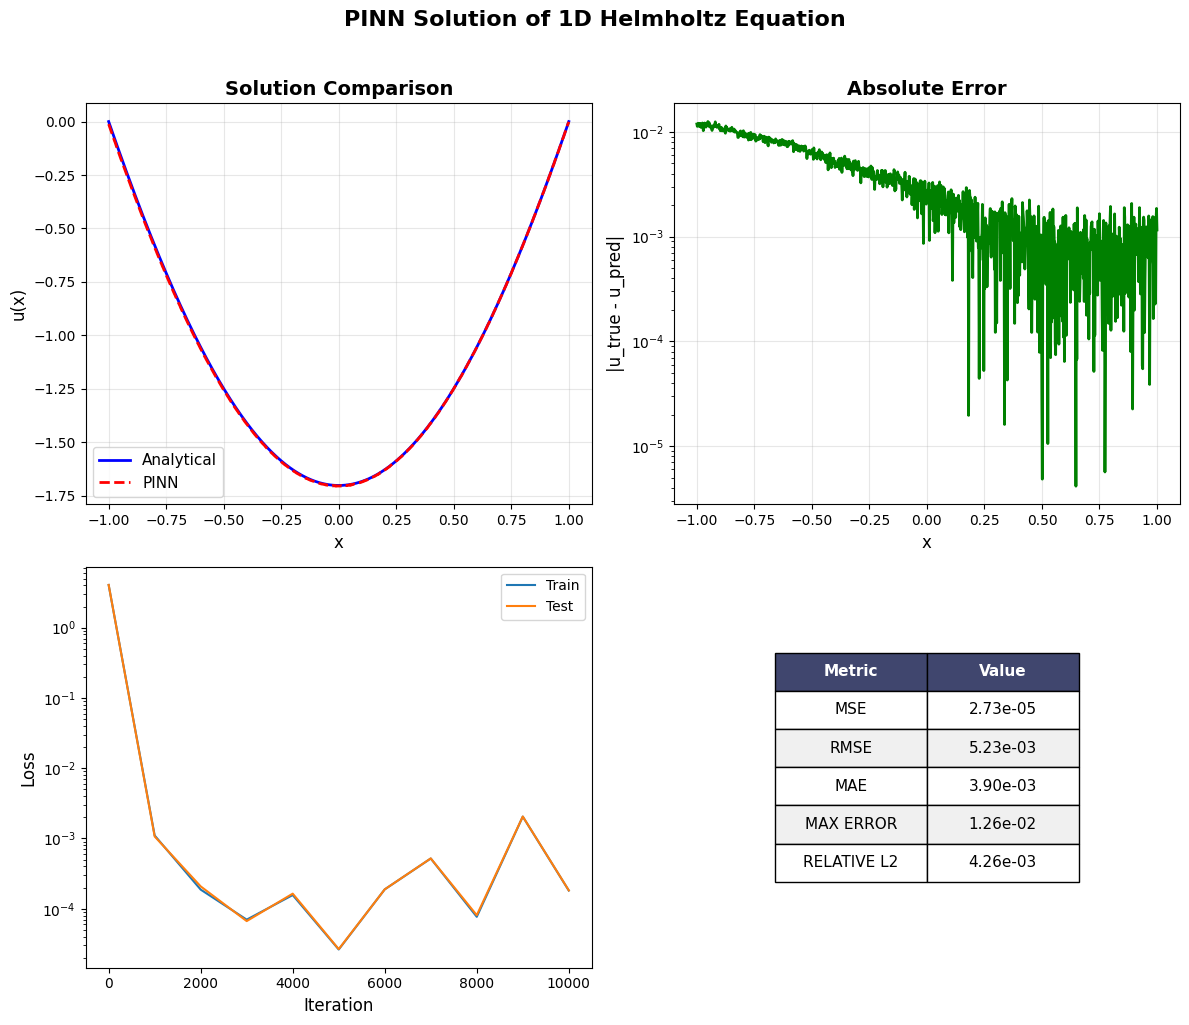


SOLUTION AT SPECIFIC POINTS
       x       u_true       u_pred        error
--------------------------------------------------
   -0.50    -1.248487    -1.254828     6.34e-03
    0.00    -1.701631    -1.704406     2.77e-03
    0.50    -1.248487    -1.250434     1.95e-03

ANALYSIS COMPLETE


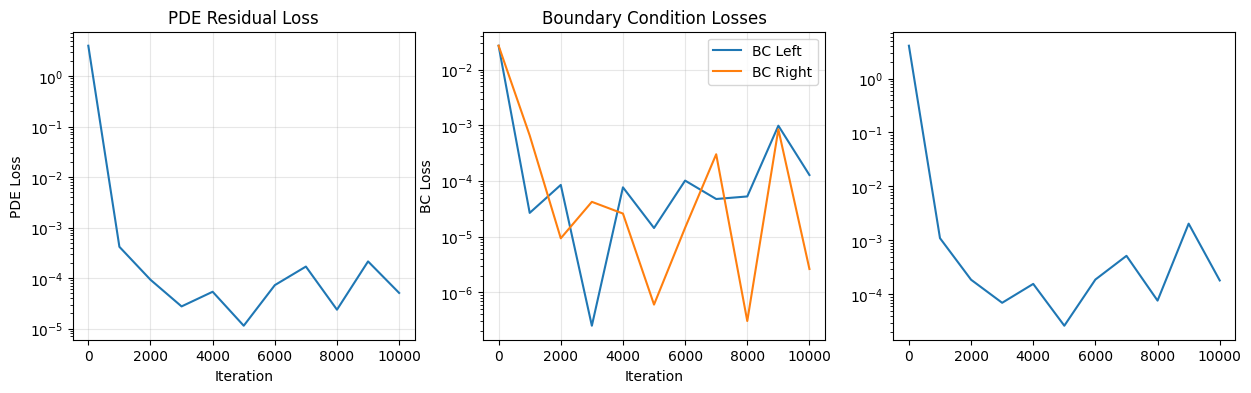

In [2]:
"""
PINN for 1D inhomogeneous Helmholtz equation
==============================================================================
Solves the 1D Helmholtz equation with DeepXDE:
    (∇² + k²)u(x) = f(x), with u(-1) = u(1) = 0
    - f(x) = 2.0 and k² = 1.0.
"""

import numpy as np
import deepxde as dde
import matplotlib.pyplot as plt
from typing import Callable, Dict, List, Tuple
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)
dde.config.set_random_seed(42)

class HelmholtzPINN:
    """
    PINN for 1D Helmholtz equation.
    """

    def __init__(self,
                 domain: Tuple[float, float] = (-1.0, 1.0),
                 G_prime: float = 1.0,
                 G_double_prime: float = 0.0,
                 rho: float = 1.0,
                 omega: float = 1.0,
                 source_value: float = 2.0):
        """
        Initialize the Helmholtz PINN solver.

        Args:
            domain: Spatial domain boundaries (x_min, x_max)
            G_prime: Storage modulus
            G_double_prime: Loss modulus
            rho: Density
            omega: Angular frequency
            source_value: Constant source term value
        """
        self.domain = domain
        self.G_prime = G_prime
        self.G_double_prime = G_double_prime
        self.rho = rho
        self.omega = omega
        self.source_value = source_value

        # Wave number
        self.k_squared = (rho * omega**2) / (G_prime + 1j * G_double_prime)
        self.k_squared = np.real(self.k_squared)  # Take real part since G'' = 0

        self.model = None
        self.losshistory = None

    def analytical_solution(self, x: np.ndarray) -> np.ndarray:
        """
        Compute the analytical solution.

        Args:
            x: Input coordinates

        Returns:
            Analytical solution values
        """
        return 2.0 * (1.0 - np.cos(x) / np.cos(1.0))

    def pde(self, x: np.ndarray, u: np.ndarray) -> np.ndarray:
        """
        PDE residual: (∇² + k²)u - f = 0

        Args:
            x: Input coordinates
            u: Solution values

        Returns:
            PDE residual
        """
        du_xx = dde.grad.hessian(u, x)

        residual = du_xx + self.k_squared * u - self.source_value
        return residual

    def setup_problem(self,
                     num_domain: int = 400,
                     num_boundary: int = 100,
                     num_test: int = 1000) -> dde.data.PDE:
        """
        Set up the PDE problem with geometry and boundary conditions.

        Args:
            num_domain: Number of collocation points in domain
            num_boundary: Number of boundary points
            num_test: Number of test points

        Returns:
            PDE problem object
        """
        geom = dde.geometry.Interval(self.domain[0], self.domain[1])

        # Dirichlet boundary conditions: u(-1) = u(1) = 0
        def boundary_left(x, on_boundary):
            return on_boundary and np.isclose(x[0], self.domain[0])

        def boundary_right(x, on_boundary):
            return on_boundary and np.isclose(x[0], self.domain[1])

        bc_left = dde.icbc.DirichletBC(geom, lambda x: 0, boundary_left)
        bc_right = dde.icbc.DirichletBC(geom, lambda x: 0, boundary_right)

        # Create PDE
        data = dde.data.PDE(
            geom,
            self.pde,
            [bc_left, bc_right],
            num_domain=num_domain,
            num_boundary=num_boundary,
            num_test=num_test,
            solution=self.analytical_solution
        )

        return data

    def build_network(self,
                     layers: List[int] = None,
                     activation: str = "tanh") -> dde.nn.FNN:
        """
        Build the neural network architecture.

        Args:
            layers: Network architecture [input, hidden1, ..., output]
            activation: Activation function

        Returns:
            Neural network model
        """
        if layers is None:
            layers = [1, 50, 50, 50, 1]  # Default architecture

        net = dde.nn.FNN(layers, activation, "Glorot uniform")
        return net

    def train(self,
             epochs: int = 15000,
             learning_rate: float = 1e-3,
             optimizer: str = "adam",
             display_every: int = 1000,
             layers: List[int] = None) -> None:
        """
        Train the PINN model.

        Args:
            epochs: Number of training epochs
            learning_rate: Learning rate for optimizer
            optimizer: Optimizer type ('adam' or 'L-BFGS-B')
            display_every: Display frequency for training progress
            layers: Neural network architecture
        """
        # Setup problem
        data = self.setup_problem()

        # Build network
        net = self.build_network(layers)

        # Create model
        self.model = dde.Model(data, net)

        # Compile model
        self.model.compile(optimizer, lr=learning_rate)

        # Train with Adam
        self.losshistory, _ = self.model.train(
            iterations=epochs,
            display_every=display_every
        )

        # Optional: Fine-tune with L-BFGS
        if optimizer.lower() == "l-bfgs-b":
            self.model.compile("L-BFGS-B")
            self.losshistory, _ = self.model.train(display_every=display_every)

    def predict(self, x: np.ndarray) -> np.ndarray:
        """
        Make predictions using the trained model.

        Args:
            x: Input coordinates

        Returns:
            Predicted solution values
        """
        if self.model is None:
            raise ValueError("Model not trained yet. Call train() first.")

        x = x.reshape(-1, 1) if x.ndim == 1 else x
        return self.model.predict(x)

    def compute_metrics(self,
                       x_test: np.ndarray = None,
                       metrics: List[str] = None) -> Dict[str, float]:
        """
        Compute evaluation metrics in a modular way.

        Args:
            x_test: Test points (if None, uses uniform grid)
            metrics: List of metric names to compute

        Returns:
            Dictionary of metric values
        """
        if metrics is None:
            metrics = ["mse", "rmse", "mae", "max_error", "relative_l2"]

        if x_test is None:
            x_test = np.linspace(self.domain[0], self.domain[1], 1000)

        x_test = x_test.reshape(-1, 1) if x_test.ndim == 1 else x_test

        # Get predictions and true values
        u_pred = self.predict(x_test).flatten()
        u_true = self.analytical_solution(x_test).flatten()

        # Define metric functions
        metric_functions = {
            "mse": lambda y_true, y_pred: np.mean((y_true - y_pred)**2),
            "rmse": lambda y_true, y_pred: np.sqrt(np.mean((y_true - y_pred)**2)),
            "mae": lambda y_true, y_pred: np.mean(np.abs(y_true - y_pred)),
            "max_error": lambda y_true, y_pred: np.max(np.abs(y_true - y_pred)),
            "r2": lambda y_true, y_pred: 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2),
            "relative_l2": lambda y_true, y_pred: np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)
        }

        # Compute requested metrics
        results = {}
        for metric in metrics:
            if metric in metric_functions:
                results[metric] = metric_functions[metric](u_true, u_pred)
            else:
                print(f"Warning: Metric '{metric}' not implemented")

        return results

    def plot_results(self,
                    n_points: int = 1000,
                    save_path: str = None) -> None:
        """
        Plot comparison between PINN and analytical solutions.

        Args:
            n_points: Number of points for plotting
            save_path: Path to save the figure (optional)
        """
        # Generate test points
        x_test = np.linspace(self.domain[0], self.domain[1], n_points).reshape(-1, 1)

        u_pred = self.predict(x_test)
        u_true = self.analytical_solution(x_test)

        fig, axes = plt.subplots(2, 2, figsize=(12, 10))

        # Plot 1: Solution comparison
        ax = axes[0, 0]
        ax.plot(x_test, u_true, 'b-', linewidth=2, label='Analytical')
        ax.plot(x_test, u_pred, 'r--', linewidth=2, label='PINN')
        ax.set_xlabel('x', fontsize=12)
        ax.set_ylabel('u(x)', fontsize=12)
        ax.set_title('Solution Comparison', fontsize=14, fontweight='bold')
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)

        # Plot 2: Absolute error
        ax = axes[0, 1]
        error = np.abs(u_true - u_pred)
        ax.plot(x_test, error, 'g-', linewidth=2)
        ax.set_xlabel('x', fontsize=12)
        ax.set_ylabel('|u_true - u_pred|', fontsize=12)
        ax.set_title('Absolute Error', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_yscale('log')

        # Plot 3: Loss history
        ax = axes[1, 0]
        if self.losshistory is not None:
            loss_train = np.sum(np.array(self.losshistory.loss_train), axis=1)
            loss_test = np.sum(self.losshistory.loss_test, axis=1) if self.losshistory.loss_test is not None else None

            ax.semilogy(self.losshistory.steps, loss_train, label='Train')
            if loss_test is not None:
                ax.semilogy(self.losshistory.steps, loss_test, label='Test')
            ax.legend()
        ax.set_xlabel('Iteration', fontsize=12)
        ax.set_ylabel('Loss', fontsize=12)

        # Plot 4: Metrics table
        ax = axes[1, 1]
        ax.axis('off')
        metrics = self.compute_metrics(x_test)

        # Create metrics table
        table_data = []
        for metric, value in metrics.items():
            if metric == "mse":
                table_data.append([metric.upper(), f"{value:.2e}"])
            elif metric == "r2":
                table_data.append(["R²", f"{value:.6f}"])
            else:
                table_data.append([metric.upper().replace("_", " "), f"{value:.2e}"])

        table = ax.table(cellText=table_data,
                        colLabels=['Metric', 'Value'],
                        cellLoc='center',
                        loc='center',
                        colWidths=[0.3, 0.3])
        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1, 2)

        for i in range(len(table_data) + 1):
            for j in range(2):
                cell = table[(i, j)]
                if i == 0:
                    cell.set_facecolor('#40466e')
                    cell.set_text_props(weight='bold', color='white')
                else:
                    cell.set_facecolor('#f0f0f0' if i % 2 == 0 else 'white')

        plt.suptitle('PINN Solution of 1D Helmholtz Equation',
                    fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')

        plt.show()

    def plot_loss_components(self) -> None:
        """
        Plot individual loss components during training.
        """
        if self.losshistory is None:
            print("No training history available.")
            return

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        loss_train = np.array(self.losshistory.loss_train)

        # PDE loss
        axes[0].semilogy(self.losshistory.steps, loss_train[:, 0])
        axes[0].set_xlabel('Iteration')
        axes[0].set_ylabel('PDE Loss')
        axes[0].set_title('PDE Residual Loss')
        axes[0].grid(True, alpha=0.3)

        # BC losses
        axes[1].semilogy(self.losshistory.steps, loss_train[:, 1], label='BC Left')
        axes[1].semilogy(self.losshistory.steps, loss_train[:, 2], label='BC Right')
        axes[1].set_xlabel('Iteration')
        axes[1].set_ylabel('BC Loss')
        axes[1].set_title('Boundary Condition Losses')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        # Total loss
        total_loss = np.sum(loss_train, axis=1)
        axes[2].semilogy(self.losshistory.steps, total_loss)


def main():
    """
    Main function.
    """
    print("=" * 70)
    print("PHYSICS-INFORMED NEURAL NETWORK FOR 1D HELMHOLTZ EQUATION")
    print("=" * 70)

    # Initialization
    solver = HelmholtzPINN(
        domain=(-1.0, 1.0),
        G_prime=1.0,
        G_double_prime=0.0,
        rho=1.0,
        omega=1.0,
        source_value=2.0
    )

    print(f"\nProblem Parameters:")
    print(f"  Domain: [{solver.domain[0]}, {solver.domain[1]}]")
    print(f"  Wave number squared (k²): {solver.k_squared:.4f}")
    print(f"  Source term f(x): {solver.source_value}")

    # Train the model
    print("\nTraining PINN model...")
    print("-" * 50)

    solver.train(
        epochs=10000,
        learning_rate=1e-3,
        optimizer="adam",
        display_every=1000,
        layers=[1, 50, 50, 50, 1]  # 3 hidden layers with 50 neurons each
    )

    print("\n" + "=" * 50)
    print("EVALUATION METRICS")
    print("=" * 50)

    metrics = solver.compute_metrics()
    for metric, value in metrics.items():
        if metric == "r2":
            print(f"  R² Score: {value:.6f}")
        else:
            metric_name = metric.upper().replace("_", " ")
            print(f"  {metric_name}: {value:.2e}")

    print("\nGenerating plots...")
    solver.plot_results()

    # Plot loss components
    solver.plot_loss_components()

    # Additional analysis: Check solution at specific points
    print("\n" + "=" * 50)
    print("SOLUTION AT SPECIFIC POINTS")
    print("=" * 50)

    test_points = np.array([-0.5, 0.0, 0.5]).reshape(-1, 1)
    u_pred = solver.predict(test_points)
    u_true = solver.analytical_solution(test_points)

    print(f"{'x':>8} {'u_true':>12} {'u_pred':>12} {'error':>12}")
    print("-" * 50)
    for i in range(len(test_points)):
        error = abs(u_true[i, 0] - u_pred[i, 0])
        print(f"{test_points[i, 0]:>8.2f} {u_true[i, 0]:>12.6f} "
              f"{u_pred[i, 0]:>12.6f} {error:>12.2e}")

    print("\n" + "=" * 70)
    print("ANALYSIS COMPLETE")
    print("=" * 70)

    return solver


if __name__ == "__main__":
    solver = main()